In [37]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np


c_rates = "C/20"
no_cycles = 2
exp = pybamm.Experiment(
    [("Charge at {} until 4.2 V".format(c_rates),
      "Rest for 5 hours",
      "Discharge at {} until 2.5 V".format(c_rates),
      "Rest for 5 hours",
      )] * no_cycles,
) 
param = pybamm.ParameterValues("Chen2020")
param['Initial inner SEI thickness [m]'] = 1e-12
param['Initial outer SEI thickness [m]'] = 1e-12
param["Negative particle radius [m]"]=5.86e-06 * 1.02
param["Negative electrode diffusivity [m2.s-1]"]=  3.3e-15
model = pybamm.lithium_ion.SPM()
solver = pybamm.CasadiSolver(mode="safe")
sim = (pybamm.Simulation(model, parameter_values=param,
                                 experiment=exp, solver=solver))

sol = sim.solve(initial_soc=0)
param

/home/kawamanmi/Projects/PyBaMM


{'Ambient temperature [K]': 298.15,
 'Boltzmann constant [J.K-1]': 1.380649e-23,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.2594,
 'Cell cooling surface area [m2]': 0.00531,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 2.42e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Edge heat transfer coefficient [W.m-2.K-1]': 0.3,
 'Electrode height [m]': 0.065,
 'Electrode width [m]': 1.58,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Nyman2008 at 0x7f87492e27a0>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Nyman2008 at 0x7f87492e2710>,
 'Electron charge [C]': 1.602176634e-19,
 'Faraday constant [C.mol-1]': 96485.33212,
 'Ideal gas constant [J.K-1.mol-1]': 8.314462618,
 'Initial concentration in electrolyte [mol.m-3]': 1000.0,
 'Initial concentration in neg

In [38]:
model.variable_names()

['Time [s]',
 'Time [min]',
 'Time [h]',
 'x [m]',
 'x_n [m]',
 'x_s [m]',
 'x_p [m]',
 'r_n [m]',
 'r_p [m]',
 'Current variable [A]',
 'Total current density [A.m-2]',
 'Current [A]',
 'C-rate',
 'Discharge capacity [A.h]',
 'Throughput capacity [A.h]',
 'Discharge energy [W.h]',
 'Throughput energy [W.h]',
 'Porosity',
 'Negative electrode porosity',
 'X-averaged negative electrode porosity',
 'Separator porosity',
 'X-averaged separator porosity',
 'Positive electrode porosity',
 'X-averaged positive electrode porosity',
 'Porosity change',
 'Negative electrode porosity change [s-1]',
 'X-averaged negative electrode porosity change [s-1]',
 'Separator porosity change [s-1]',
 'X-averaged separator porosity change [s-1]',
 'Positive electrode porosity change [s-1]',
 'X-averaged positive electrode porosity change [s-1]',
 'Negative electrode interface utilisation variable',
 'X-averaged negative electrode interface utilisation variable',
 'Negative electrode interface utilisation',


In [39]:
# import matplotlib.pyplot as plt
# model.variable_names()
# plt.plot(sol["Time [h]"].entries,
#          sol['Battery open-circuit voltage [V]'].entries)
sim.plot(output_variables=['Battery negative particle concentration overpotential [V]','X-averaged negative electrode reaction overpotential [V]'])

interactive(children=(FloatSlider(value=0.0, description='t', max=100.83048567258737, step=1.0083048567258737)…

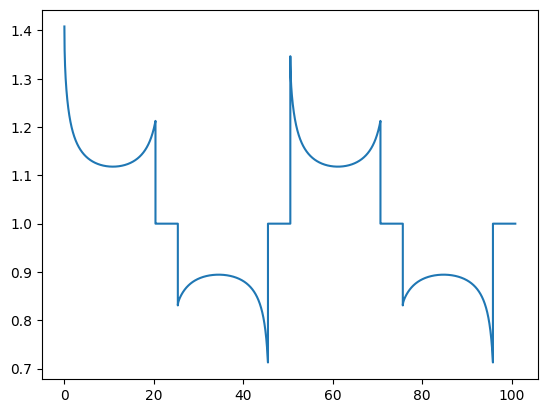

In [40]:
import matplotlib.pyplot as plt
t = sol["Time [h]"].entries
ets = sol['X-averaged negative electrode reaction overpotential [V]'].entries

ep = np.exp(-0.5*38.92*ets)
plt.plot(t,ep)


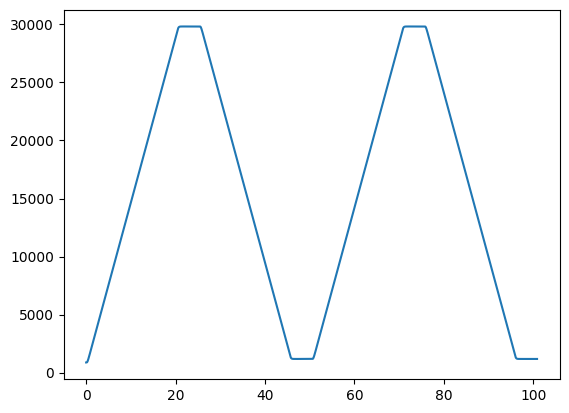

In [41]:
import matplotlib.pyplot as plt
cn = sol['X-averaged negative particle concentration [mol.m-3]'].entries[0]
t = sol['Time [h]'].entries
plt.plot(t, cn)

In [42]:
phi_n = sol['X-averaged negative electrode potential [V]'].entries[0]
phi_e = sol['X-averaged electrolyte potential [V]'].entries[0]
print(phi_n - phi_e)
'X-averaged negative particle concentration [mol.m-3]'

1.087843744242197


'X-averaged negative particle concentration [mol.m-3]'

In [43]:

D_SEI = [1]
Kinetic_constants = [1/1000]
sols = []
pybamm.settings.max_y_value = 1000000000
solver = pybamm.CasadiSolver(mode="safe")
for ii in Kinetic_constants:
    for i in D_SEI:
        param = pybamm.ParameterValues("Chen2020")

        param['Outer SEI solvent diffusivity [m2.s-1]'] = param['Outer SEI solvent diffusivity [m2.s-1]']/100
        param['SEI kinetic rate constant [m.s-1]'] = param['SEI kinetic rate constant [m.s-1]']*ii
        Factor = param['SEI kinetic rate constant [m.s-1]'] * \
            param['Faraday constant [C.mol-1]'] * \
            param['Bulk solvent concentration [mol.m-3]']
        print(Factor)

        sim = (pybamm.Simulation(model, parameter_values=param,
                                 experiment=exp, solver=solver))
        sols.append(sim.solve(initial_soc=0))

2.5433533546832e-07


In [44]:
out_vars = ['X-averaged negative total SEI thickness [m]', 'X-averaged negative particle surface concentration [mol.m-3]',
            "Voltage [V]",
            ]

In [45]:
param_R = pybamm.ParameterValues("Chen2020")
param_R['Initial inner SEI thickness [m]'] = 1e-12
param_R['Initial outer SEI thickness [m]'] = 1e-12
param_R['SEI reaction exchange current density [A.m-2]'] = 2.5433446e-7
model_R = (pybamm.lithium_ion.SPM(
    options={"SEI": "reaction limited", "SEI porosity change": "true"},
    name=sei_model))
sim_R = (pybamm.Simulation(model_R, parameter_values=param_R,
                           experiment=exp, solver=solver))
sol_R = sim_R.solve(initial_soc=0)

param_D = pybamm.ParameterValues("Chen2020")
param_D['Initial inner SEI thickness [m]'] = 1e-12
param_D['Initial outer SEI thickness [m]'] = 1e-12
model_D = (pybamm.lithium_ion.SPM(
    options={"SEI": "solvent-diffusion limited",
             "SEI porosity change": "true"},
    name=sei_model))
sim_D = (pybamm.Simulation(model_D, parameter_values=param_D,
                           experiment=exp, solver=solver))
sol_D = sim_D.solve(initial_soc=0)

NameError: name 'sei_model' is not defined

In [ ]:
# model_D.variable_names()

In [ ]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.cm as cm

plt.style.use('science')  # Use the 'science' style
cmap = cm.get_cmap('tab10')  # Colour map (there are many others)
out_vars = ['X-averaged negative total SEI thickness [m]', 'X-averaged negative particle surface concentration [mol.m-3]',
            "Voltage [V]",
            ]
print(len(sols))
for index in range(len(sols)):
    plt.plot(sols[index]["Time [h]"].entries,
             sols[index][out_vars[0]].entries, label=index)
plt.plot(sol_D["Time [h]"].entries, sol_D[out_vars[0]].entries,
         label="DD", color='black', linestyle=':')
plt.plot(sol_R["Time [h]"].entries, sol_R[out_vars[0]].entries,
         label="RR", color='black', linestyle='--')
plt.xlabel("Time [h]")
plt.ylabel(out_vars[0])
plt.legend()